In [5]:
!unzip -o -q "/content/Project8_pdm_Predictive Maintenance of gearboxdata.zip" -d "/content/project8"

In [6]:
import os

print(os.listdir("/content/project8"))

['Project8_pdm_Predictive Maintenance of gearboxdata']


In [7]:
import os

path = "/content/project8/Project8_pdm_Predictive Maintenance of gearboxdata"

print(os.listdir(path))

['Project8_pdm_Predictive Maintenance of gearboxdata.docx', 'gearbox-reliability-collaborative-phase-3-gearbox-2-test-1.pdf', 'Project8_pdm_Predictive Maintenance of gearboxdata.zip']


In [8]:
!unzip -q "/content/project8/Project8_pdm_Predictive Maintenance of gearboxdata/Project8_pdm_Predictive Maintenance of gearboxdata.zip" -d "/content/gearbox_data"

In [9]:
import os

print(os.listdir("/content/gearbox_data"))

['BrokenTooth Data', 'Healthy Data']


In [10]:
import os

healthy_path = "/content/gearbox_data/Healthy Data"
broken_path = "/content/gearbox_data/BrokenTooth Data"

healthy_files = sorted(os.listdir(healthy_path))
broken_files = sorted(os.listdir(broken_path))

print("Healthy files :", len(healthy_files))
print("Broken files  :", len(broken_files))

print("\nFirst Healthy File :", healthy_files[0])
print("First Broken File  :", broken_files[0])

Healthy files : 10
Broken files  : 10

First Healthy File : h30hz0.txt
First Broken File  : b30hz0.txt


In [11]:
import pandas as pd

sample = pd.read_csv(
    os.path.join(healthy_path, healthy_files[0]),
    sep="\t",
    header=None
)

sample.head()

,0,1,2,3,4
0,4.636710,0.516978,-3.205940,1.82241,NaN
1,1.992800,4.184660,-2.740610,2.80436,NaN
2,-3.764110,0.997335,-1.303090,1.83668,NaN
3,-4.558710,6.104330,-1.720690,1.72311,NaN
4,0.575382,0.170980,-0.497967,-1.32895,NaN


In [12]:
sample = sample.dropna(axis=1)

sample.head()

,0,1,2,3
0,4.636710,0.516978,-3.205940,1.82241
1,1.992800,4.184660,-2.740610,2.80436
2,-3.764110,0.997335,-1.303090,1.83668
3,-4.558710,6.104330,-1.720690,1.72311
4,0.575382,0.170980,-0.497967,-1.32895


In [13]:
sample.shape

(88832, 4)

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

In [15]:
def extract_features(df):

    features = {}

    for col in df.columns:

        signal = df[col]

        features[f"mean_{col}"] = signal.mean()
        features[f"std_{col}"] = signal.std()
        features[f"max_{col}"] = signal.max()
        features[f"min_{col}"] = signal.min()

        features[f"rms_{col}"] = np.sqrt(np.mean(signal**2))

        features[f"kurtosis_{col}"] = kurtosis(signal)

        features[f"skew_{col}"] = skew(signal)

    return features

In [16]:
features = extract_features(sample)

pd.DataFrame([features]).head()

,mean_0,std_0,max_0,min_0,rms_0,kurtosis_0,skew_0,mean_1,std_1,max_1,...,rms_2,kurtosis_2,skew_2,mean_3,std_3,max_3,min_3,rms_3,kurtosis_3,skew_3
0,-0.022179,5.946117,39.2677,-38.4144,5.946125,3.133808,-0.070615,0.007026,4.156326,29.2146,...,3.25209,2.392366,-0.110487,-0.007266,3.361671,25.9776,-21.0146,3.36166,2.334731,0.094172


In [18]:
dataset = []

for file in healthy_files:

    df = pd.read_csv(
        os.path.join(healthy_path, file),
        sep="\t",
        header=None
    )

    df = df.dropna(axis=1)

    features = extract_features(df)

    features["label"] = 0

    dataset.append(features)

for file in broken_files:

    df = pd.read_csv(
        os.path.join(broken_path, file),
        sep="\t",
        header=None
    )

    df = df.dropna(axis=1)

    features = extract_features(df)

    features["label"] = 1

    dataset.append(features)

In [19]:
gearbox_df = pd.DataFrame(dataset)

gearbox_df.head()

,mean_0,std_0,max_0,min_0,rms_0,kurtosis_0,skew_0,mean_1,std_1,max_1,...,kurtosis_2,skew_2,mean_3,std_3,max_3,min_3,rms_3,kurtosis_3,skew_3,label
0,-0.022179,5.946117,39.2677,-38.4144,5.946125,3.133808,-0.070615,0.007026,4.156326,29.2146,...,2.392366,-0.110487,-0.007266,3.361671,25.9776,-21.0146,3.361660,2.334731,0.094172,0
1,0.037409,6.013605,40.1420,-43.7555,6.013689,3.403795,-0.084048,-0.014579,4.193539,27.8999,...,2.418856,-0.009844,-0.013202,3.453247,27.1891,-21.2636,3.453253,2.244003,0.101141,0
2,-0.030569,6.291892,44.2909,-48.3062,6.291938,2.955723,0.087834,0.006509,4.214848,29.1924,...,2.387239,-0.136576,-0.000023,3.642440,37.3499,-28.6636,3.642423,2.341184,-0.119421,0
3,0.003779,6.961558,53.3409,-51.7640,6.961527,2.690139,0.118853,-0.002020,4.290782,28.9619,...,2.120006,-0.143777,0.015439,4.082466,23.0756,-23.8750,4.082476,1.655133,-0.246118,0
4,-0.012099,7.558153,50.2297,-49.5432,7.558125,2.659027,0.127076,0.002885,4.509020,30.9283,...,1.749521,-0.178004,0.001601,4.534764,31.0125,-27.3114,4.534741,1.769613,-0.161492,0


In [20]:
gearbox_df.shape

(20, 29)

In [21]:
from tqdm import tqdm

In [23]:
X = gearbox_df.drop("label", axis=1)
y = gearbox_df["label"]

print(X.shape)
print(y.shape)

(20, 28)
(20,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(16, 28)
(4, 28)


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 0]
 [0 2]]


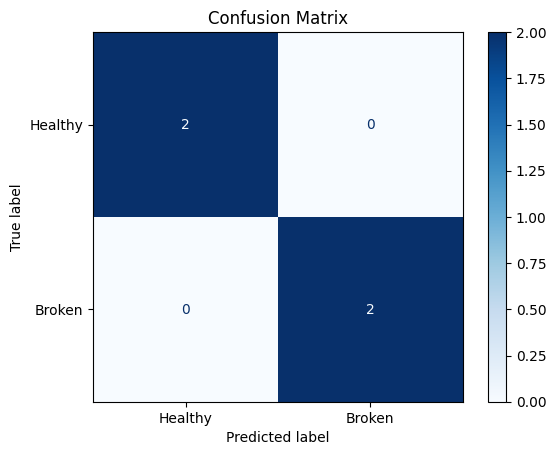

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Broken"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

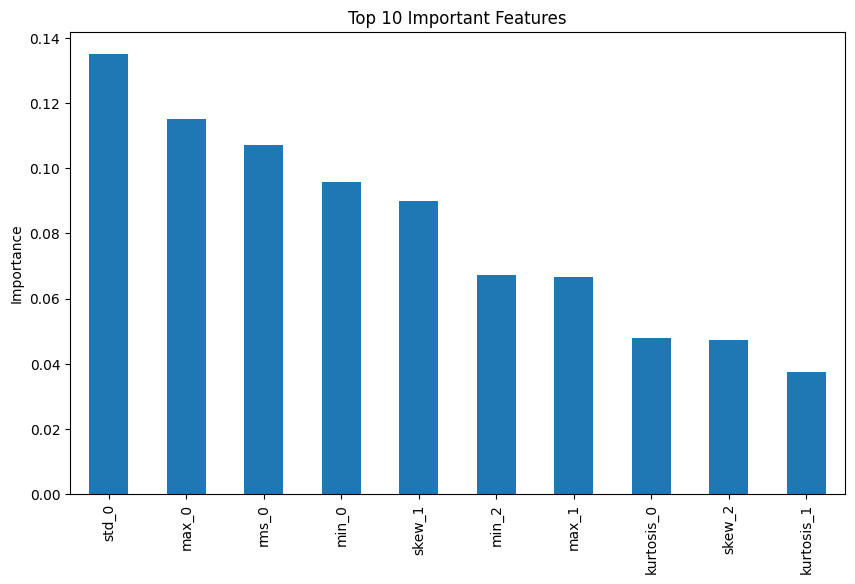

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

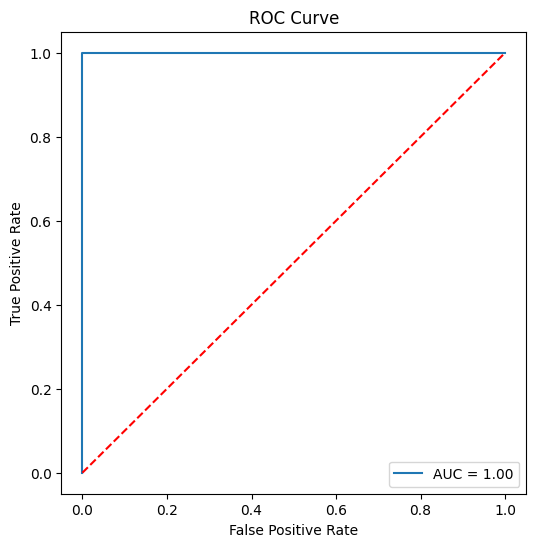

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
import joblib

joblib.dump(model, "gearbox_fault_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [35]:
loaded_model = joblib.load("gearbox_fault_model.pkl")

prediction = loaded_model.predict(X_test)

print(prediction)

[0 0 1 1]


In [36]:
gearbox_df.to_csv("gearbox_features.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [37]:
print("Shape :", gearbox_df.shape)
print("\nColumns:")
print(gearbox_df.columns)

print("\nMissing Values:")
print(gearbox_df.isnull().sum())

Shape : (20, 29)

Columns:
Index(['mean_0', 'std_0', 'max_0', 'min_0', 'rms_0', 'kurtosis_0', 'skew_0',
       'mean_1', 'std_1', 'max_1', 'min_1', 'rms_1', 'kurtosis_1', 'skew_1',
       'mean_2', 'std_2', 'max_2', 'min_2', 'rms_2', 'kurtosis_2', 'skew_2',
       'mean_3', 'std_3', 'max_3', 'min_3', 'rms_3', 'kurtosis_3', 'skew_3',
       'label'],
      dtype='object')

Missing Values:
mean_0        0
std_0         0
max_0         0
min_0         0
rms_0         0
kurtosis_0    0
skew_0        0
mean_1        0
std_1         0
max_1         0
min_1         0
rms_1         0
kurtosis_1    0
skew_1        0
mean_2        0
std_2         0
max_2         0
min_2         0
rms_2         0
kurtosis_2    0
skew_2        0
mean_3        0
std_3         0
max_3         0
min_3         0
rms_3         0
kurtosis_3    0
skew_3        0
label         0
dtype: int64


In [38]:
gearbox_df.describe()

,mean_0,std_0,max_0,min_0,rms_0,kurtosis_0,skew_0,mean_1,std_1,max_1,...,kurtosis_2,skew_2,mean_3,std_3,max_3,min_3,rms_3,kurtosis_3,skew_3,label
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.001333,5.928430,35.970950,-36.139980,5.928418,1.525686,0.071888,0.000291,4.392407,25.385475,...,1.690260,-0.091283,0.000390,4.402040,27.626700,-24.681430,4.402044,1.526943,-0.086380,0.500000
std,0.014861,1.625028,13.225143,13.367537,1.625025,0.931567,0.072269,0.005082,0.307349,3.527646,...,0.585708,0.054963,0.015642,0.708707,3.985978,3.048661,0.708711,0.538665,0.103620,0.512989
min,-0.030569,3.554499,19.048900,-58.721600,3.554479,0.514283,-0.084048,-0.014579,3.922028,19.456800,...,0.858352,-0.178004,-0.030285,3.331703,21.069600,-31.334500,3.331688,0.804474,-0.246118,0.000000
25%,-0.003713,4.692828,24.229125,-49.381425,4.692811,0.880575,0.037228,-0.002216,4.184236,23.244000,...,1.086342,-0.144364,-0.007843,3.666078,25.378425,-27.293325,3.666062,0.939054,-0.161498,0.000000
50%,0.001418,5.636250,32.818900,-31.880250,5.636242,1.193846,0.078809,0.000524,4.402218,24.590550,...,1.644216,-0.095737,0.000443,4.565599,26.346850,-24.397400,4.565577,1.543384,-0.128199,0.500000
75%,0.007018,7.521371,48.524875,-24.131875,7.521345,2.108942,0.122519,0.003046,4.612378,29.019525,...,2.277910,-0.040357,0.009656,5.079255,30.612075,-23.005700,5.079284,2.010027,-0.042912,1.000000
max,0.037409,8.266885,56.706600,-21.826000,8.266868,3.403795,0.166037,0.008212,4.986792,30.928300,...,2.581403,-0.009844,0.035857,5.242376,37.349900,-18.617300,5.242370,2.341184,0.105467,1.000000


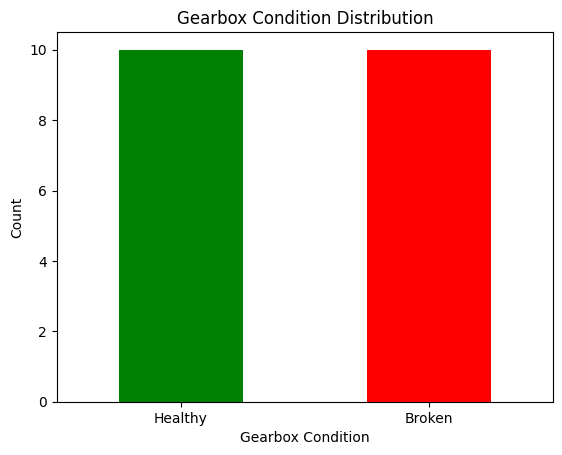

In [39]:
import matplotlib.pyplot as plt

gearbox_df["label"].value_counts().plot(
    kind="bar",
    color=["green", "red"]
)

plt.xticks([0,1], ["Healthy", "Broken"], rotation=0)
plt.xlabel("Gearbox Condition")
plt.ylabel("Count")
plt.title("Gearbox Condition Distribution")
plt.show()

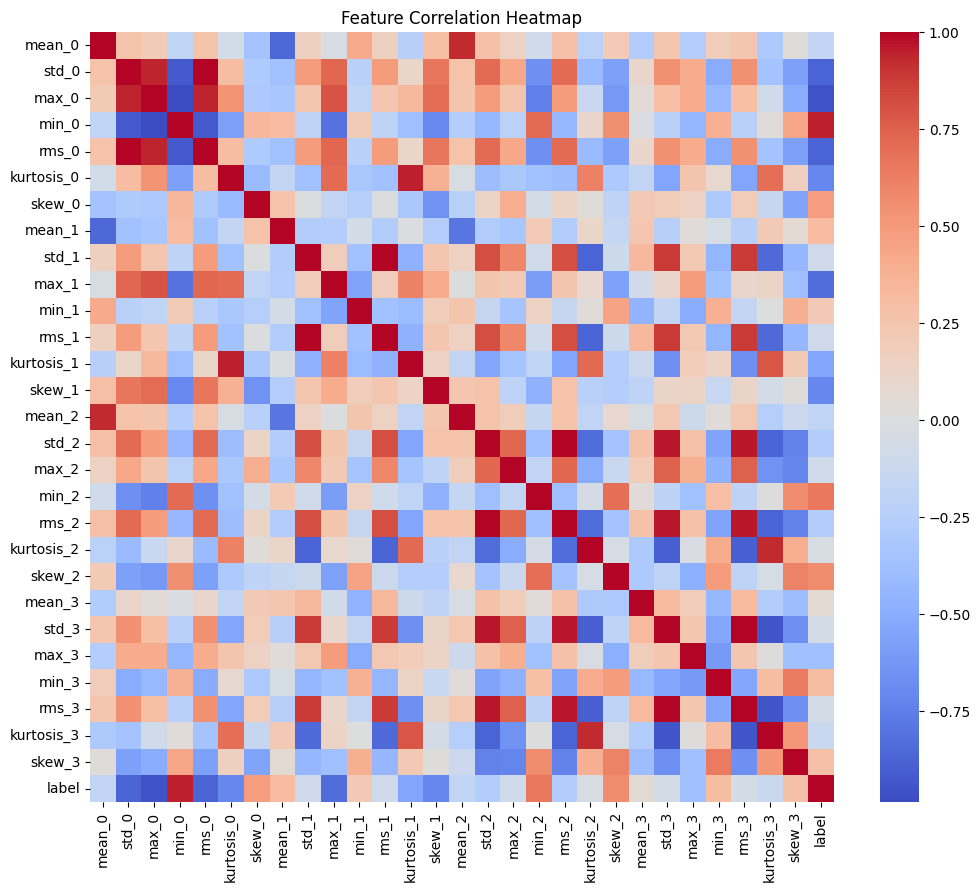

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    gearbox_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

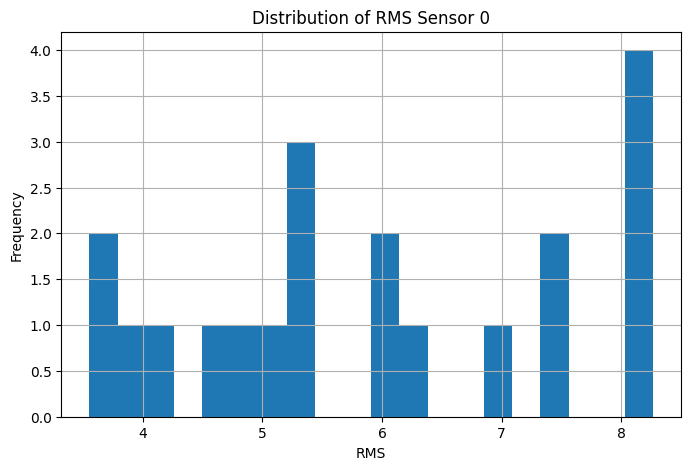

In [41]:
plt.figure(figsize=(8,5))

gearbox_df["rms_0"].hist(bins=20)

plt.title("Distribution of RMS Sensor 0")
plt.xlabel("RMS")
plt.ylabel("Frequency")

plt.show()

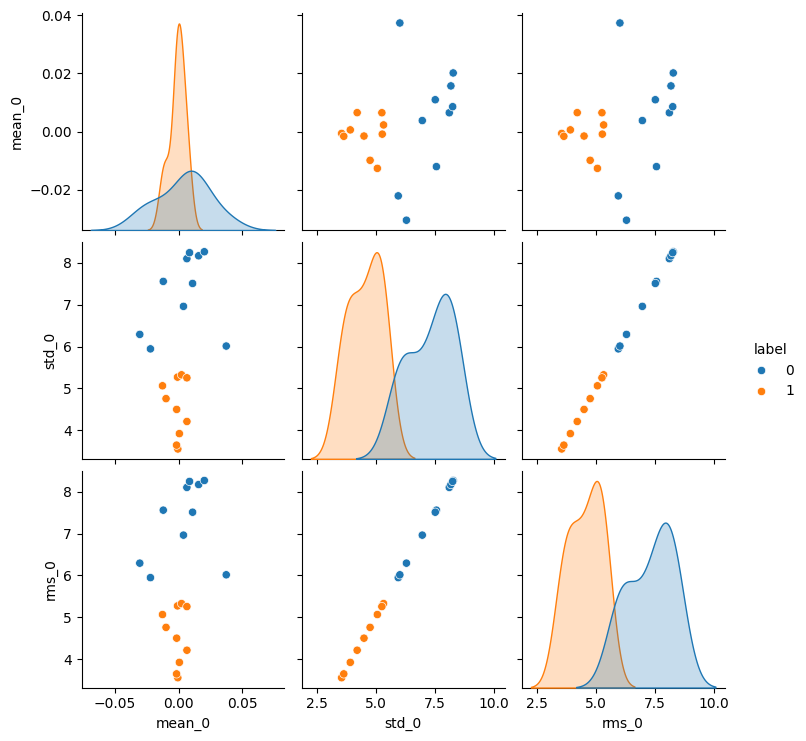

In [42]:
sns.pairplot(
    gearbox_df[
        ["mean_0","std_0","rms_0","label"]
    ],
    hue="label"
)

plt.show()

In [47]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [48]:
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [49]:
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [50]:
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>